# AdventureWorks DW — Production-Grade ETL Pipeline v2
**Author:** AdventureWorks Analytics Team  
**Version:** 2.0 — Validation | Surrogate Keys | SCD Type 2 | RFM Segmentation | SARIMA Forecast

---
## Data Lineage
```
Raw Excel Files (FactInternetSales, FactResellerSales, DimTables)
        ↓
Step 1 : Extract           — Load all 8 source sheets
        ↓
Step 2 : Validate          — 15 assertion checks + DQ report table
        ↓
Step 3 : Clean             — Nulls, duplicates, type casting, date parsing
        ↓
Step 4 : Feature Engineer  — Profit, Margin, UnitPrice, AgeGroup, Segments, Surrogate Keys
        ↓
Step 5 : SCD Type 2        — EffectiveDate / EndDate / IsCurrent (dim_customer, dim_product)
        ↓
Step 6 : DimDate           — Calendar + Fiscal + Holiday + Season flags
        ↓
Step 7 : EDA               — Revenue overview, customer segment, category charts
        ↓
Step 8 : RFM Segmentation  — Champions, Loyal, Potential, At Risk, Lost
        ↓
Step 9 : SARIMA Forecast   — 12-month internet sales projection
        ↓
Step 10: Load to MySQL     — adventureworks_dw (9 tables)
        ↓
Step 11: Export CSV        — powerbi_data/ folder (10 files)
        ↓
Power BI Dashboard
```

---
## Step 0 — Libraries

In [87]:
# !pip install pandas numpy sqlalchemy pymysql openpyxl statsmodels matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

from sqlalchemy import create_engine, text

pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams.update({'figure.dpi': 130, 'font.family': 'sans-serif'})
print(f'pandas {pd.__version__} | numpy {np.__version__} | Libraries loaded')

pandas 2.2.0 | numpy 1.26.4 | Libraries loaded


---
## Step 1 — EXTRACT

In [ ]:
FACT_INTERNET = 'FactInternetSales.xlsx'
FACT_RESELLER = 'FactResellerSales.xlsx'
DIM_TABLES    = 'DimTables.xlsx'
fact_internet = pd.read_excel(FACT_INTERNET)
fact_reseller = pd.read_excel(FACT_RESELLER)
dim_customer  = pd.read_excel(DIM_TABLES, sheet_name='DimCustomer')
dim_product   = pd.read_excel(DIM_TABLES, sheet_name='DimProduct')
dim_reseller  = pd.read_excel(DIM_TABLES, sheet_name='DimReseller')
dim_geography = pd.read_excel(DIM_TABLES, sheet_name='DimGeography')
dim_territory = pd.read_excel(DIM_TABLES, sheet_name='DimSalesTerritory')
dim_employee  = pd.read_excel(DIM_TABLES, sheet_name='DimEmployee')

print('Extraction complete')
for name, df in [('FactInternetSales',fact_internet),('FactResellerSales',fact_reseller),
                ('DimCustomer',dim_customer),('DimProduct',dim_product),
                ('DimReseller',dim_reseller),('DimGeography',dim_geography),
                ('DimSalesTerritory',dim_territory),('DimEmployee',dim_employee)]:
    print(f'  {name:25s}: {df.shape[0]:>7,} rows  {df.shape[1]} cols')

Extraction complete
  FactInternetSales        :  60,398 rows  13 cols
  FactResellerSales        :  60,899 rows  14 cols
  DimCustomer              :  18,484 rows  13 cols
  DimProduct               :     397 rows  7 cols
  DimReseller              :     701 rows  4 cols
  DimGeography             :     655 rows  6 cols
  DimSalesTerritory        :      11 rows  4 cols
  DimEmployee              :      21 rows  9 cols


---
## Step 2 — VALIDATE: Assertion Rules + DQ Report

In [89]:
# Parse dates first so assertions can use them
for col in ['OrderDate','DueDate','ShipDate']:
    fact_internet[col] = pd.to_datetime(fact_internet[col], errors='coerce')
    fact_reseller[col] = pd.to_datetime(fact_reseller[col], errors='coerce')
dim_customer['BirthDate'] = pd.to_datetime(dim_customer['BirthDate'], errors='coerce')
dim_customer['FirstPurchaseDate'] = pd.to_datetime(dim_customer['FirstPurchaseDate'], errors='coerce')
dim_employee['BirthDate'] = pd.to_datetime(dim_employee['BirthDate'], errors='coerce')
dim_employee['HireDate']  = pd.to_datetime(dim_employee['HireDate'],  errors='coerce')
print('Dates parsed')

Dates parsed


In [90]:
# DATA VALIDATION — 15 assertion checks with report
results = []

def chk(name, cond, detail=''):
    results.append({'Check': name, 'Status': 'PASS' if cond else 'FAIL', 'Detail': detail})

# Fact: Internet
chk('FIS: No negative SalesAmount',
    fact_internet['SalesAmount'].min() >= 0,
    f'min={fact_internet["SalesAmount"].min():.2f}')
chk('FIS: No negative ProductCost',
    fact_internet['TotalProductCost'].min() >= 0,
    f'min={fact_internet["TotalProductCost"].min():.2f}')
chk('FIS: No future OrderDates',
    fact_internet['OrderDate'].max() <= pd.Timestamp.today(),
    f'max={fact_internet["OrderDate"].max().date()}')
chk('FIS: OrderDate not null',
    fact_internet['OrderDate'].isnull().sum() == 0,
    f'nulls={fact_internet["OrderDate"].isnull().sum()}')
chk('FIS: ShipDate >= OrderDate',
    (fact_internet['ShipDate'] >= fact_internet['OrderDate']).all(),
    'Ship must not precede Order')
chk('FIS: All ProductKeys in DimProduct',
    fact_internet['ProductKey'].isin(dim_product['ProductKey']).all(),
    f'orphans={fact_internet[~fact_internet["ProductKey"].isin(dim_product["ProductKey"])].shape[0]}')
chk('FIS: All CustomerKeys in DimCustomer',
    fact_internet['CustomerKey'].isin(dim_customer['CustomerKey']).all(),
    f'orphans={fact_internet[~fact_internet["CustomerKey"].isin(dim_customer["CustomerKey"])].shape[0]}')
chk('FIS: No duplicate OrderLine keys',
    fact_internet.duplicated(['SalesOrderNumber','SalesOrderLineNumber']).sum() == 0,
    f'dupes={fact_internet.duplicated(["SalesOrderNumber","SalesOrderLineNumber"]).sum()}')

# Fact: Reseller
chk('FRS: No negative SalesAmount',
    fact_reseller['SalesAmount'].dropna().min() >= 0, '')
chk('FRS: No future OrderDates',
    fact_reseller['OrderDate'].max() <= pd.Timestamp.today(),
    f'max={fact_reseller["OrderDate"].max().date()}')
chk('FRS: All ResellerKeys in DimReseller',
    fact_reseller['ResellerKey'].dropna().isin(dim_reseller['ResellerKey']).all(), '')

# Dimensions
chk('DimCustomer: No duplicate CustomerKey',
    dim_customer['CustomerKey'].duplicated().sum() == 0, '')
chk('DimProduct: No duplicate ProductKey',
    dim_product['ProductKey'].duplicated().sum() == 0, '')
chk('DimCustomer: YearlyIncome positive',
    (dim_customer['YearlyIncome'].fillna(1) > 0).all(), '')
chk('DimGeography: No duplicate GeographyKey',
    dim_geography['GeographyKey'].duplicated().sum() == 0, '')

vdf = pd.DataFrame(results)
pass_n = vdf['Status'].str.contains('PASS').sum()
fail_n = vdf['Status'].str.contains('FAIL').sum()

print(f'VALIDATION REPORT   PASS: {pass_n}  FAIL: {fail_n}  of {len(vdf)} checks')

print(vdf.to_string(index=False))

if fail_n == 0:
    print('\nAll checks passed - safe to proceed.')
else:
    print(f'\n{fail_n} check(s) failed - review before loading to warehouse.')

VALIDATION REPORT   PASS: 15  FAIL: 0  of 15 checks
                                  Check Status                      Detail
           FIS: No negative SalesAmount   PASS                    min=2.29
           FIS: No negative ProductCost   PASS                    min=0.86
              FIS: No future OrderDates   PASS              max=2014-01-28
                FIS: OrderDate not null   PASS                     nulls=0
             FIS: ShipDate >= OrderDate   PASS Ship must not precede Order
     FIS: All ProductKeys in DimProduct   PASS                   orphans=0
   FIS: All CustomerKeys in DimCustomer   PASS                   orphans=0
       FIS: No duplicate OrderLine keys   PASS                     dupes=0
           FRS: No negative SalesAmount   PASS                            
              FRS: No future OrderDates   PASS              max=2013-11-29
   FRS: All ResellerKeys in DimReseller   PASS                            
  DimCustomer: No duplicate CustomerKey   PASS  

---
## Step 3 — CLEAN

In [91]:
# CLEAN: Fact Tables + add OrderDateKey (INT) for efficient joins

fi = fact_internet.copy()
fi.drop_duplicates(subset=['SalesOrderNumber','SalesOrderLineNumber'], inplace=True)
fi.dropna(subset=['SalesAmount','TotalProductCost','OrderDate'], inplace=True)
fi['DiscountAmount'].fillna(0, inplace=True)
fi['Freight'].fillna(0, inplace=True)
fi.drop(columns=['CarrierTrackingNumber'], inplace=True)
fi['ProductKey']        = fi['ProductKey'].astype(int)
fi['CustomerKey']       = fi['CustomerKey'].astype(int)
fi['SalesTerritoryKey'] = fi['SalesTerritoryKey'].astype(int)

# Surrogate date keys — avoids expensive DATE_FORMAT() joins in SQL
fi['OrderDateKey'] = fi['OrderDate'].dt.strftime('%Y%m%d').astype(int)
fi['DueDateKey']   = fi['DueDate'].dt.strftime('%Y%m%d').astype(int)
fi['ShipDateKey']  = fi['ShipDate'].dt.strftime('%Y%m%d').astype(int)
print(f'FactInternetSales cleaned: {fi.shape}')

fr = fact_reseller.copy()
fr.drop_duplicates(subset=['SalesOrderNumber','SalesOrderLineNumber'], inplace=True)
fr.dropna(subset=['ProductKey','ResellerKey','SalesAmount'], inplace=True)
fr['DiscountAmount'].fillna(0, inplace=True)
fr['Freight'].fillna(0, inplace=True)
fr.drop(columns=['CarrierTrackingNumber'], inplace=True)
for col in ['ProductKey','ResellerKey','EmployeeKey','SalesTerritoryKey']:
    fr[col] = fr[col].astype(int)
fr['OrderDateKey'] = fr['OrderDate'].dt.strftime('%Y%m%d').astype(int)
fr['DueDateKey']   = fr['DueDate'].dt.strftime('%Y%m%d').astype(int)
fr['ShipDateKey']  = fr['ShipDate'].dt.strftime('%Y%m%d').astype(int)
print(f'FactResellerSales cleaned:  {fr.shape}')

FactInternetSales cleaned: (60398, 15)
FactResellerSales cleaned:  (60855, 16)


In [92]:
# CLEAN: Dimensions
dc = dim_customer.copy()
dc.drop_duplicates(subset=['CustomerKey'], inplace=True)
dc['Gender']        = dc['Gender'].str.upper().map({'M':'Male','F':'Female'}).fillna('Unknown')
dc['MaritalStatus'] = dc['MaritalStatus'].str.upper().map({'M':'Married','S':'Single'}).fillna('Unknown')
dc['YearlyIncome'].fillna(dc['YearlyIncome'].median(), inplace=True)
for col in ['Occupation','Education']: dc[col].fillna('Unknown', inplace=True)

dp = dim_product.copy()
dp.drop_duplicates(subset=['ProductKey'], inplace=True)
for col in ['Product','Category','Subcategory','Color','Model']:
    dp[col] = dp[col].astype(str).str.strip().str.title()
dp['Color'].replace('Nan','NA', inplace=True)

dg = dim_geography.copy()
dg.drop_duplicates(subset=['GeographyKey'], inplace=True)
for col in ['City','State','Country']: dg[col] = dg[col].astype(str).str.strip().str.title()

dt = dim_territory.copy(); dt.drop_duplicates(subset=['SalesTerritoryKey'], inplace=True)
dr = dim_reseller.copy();  dr.drop_duplicates(subset=['ResellerKey'], inplace=True)
dr['ResellerName'] = dr['ResellerName'].str.strip()
dr['BusinessType']  = dr['BusinessType'].str.strip()
de = dim_employee.copy();  de.drop_duplicates(subset=['EmployeeKey'], inplace=True)
print('All 6 dimensions cleaned.')

All 6 dimensions cleaned.


---
## Step 4 — FEATURE ENGINEERING + SURROGATE KEYS

In [93]:
# Fact Table Features 
for df, name in [(fi,'Internet'),(fr,'Reseller')]:
    df['Revenue']       = df['SalesAmount']
    df['Profit']        = df['SalesAmount'] - df['TotalProductCost']
    df['ProfitMargin']  = (df['Profit'] / df['SalesAmount'].replace(0,np.nan)*100).round(2)
    df['DiscountRate']  = (df['DiscountAmount'] / df['SalesAmount'].replace(0,np.nan)*100).round(2).fillna(0)
    # UnitPrice = SalesAmount / SalesOrderLineNumber (line quantity proxy)
    df['UnitPrice']     = (df['SalesAmount'] / df['SalesOrderLineNumber'].replace(0,np.nan)).round(2)
    df['OrderYear']     = df['OrderDate'].dt.year
    df['OrderMonth']    = df['OrderDate'].dt.month
    df['OrderQuarter']  = df['OrderDate'].dt.quarter
    df['DaysToShip']    = (df['ShipDate'] - df['OrderDate']).dt.days
    df['DaysToDue']     = (df['DueDate']  - df['OrderDate']).dt.days
    print(f'{name} features added')

fr['ResellerMargin'] = (fr['Profit'] / fr['TotalProductCost'].replace(0,np.nan)*100).round(2)

# DimCustomer Features 
REF = pd.Timestamp('2014-12-31')
dc['Age'] = ((REF - dc['BirthDate']).dt.days / 365.25).fillna(0).astype(int).clip(lower=0)

dc['AgeGroup'] = pd.cut(dc['Age'], bins=[0,25,35,45,55,150],
                        labels=['18-25','26-35','36-45','46-55','55+'])

dc['IncomeBand'] = pd.cut(dc['YearlyIncome'],
                        bins=[0,40000,80000,120000,1e9],
                        labels=['Low (<40K)','Mid (40K-80K)','High (80K-120K)','Very High (120K+)'])

dc['CustomerSegment'] = pd.cut(dc['YearlyIncome'],
                        bins=[0,40000,80000,120000,1e9],
                        labels=['Budget','Standard','Premium','Luxury'])

dc['TenureYears']    = ((REF - dc['FirstPurchaseDate']).dt.days / 365.25).round(1)
dc['LoyaltySegment'] = pd.cut(dc['TenureYears'],
                        bins=[-1,2,5,100],
                        labels=['New (<2 Yr)','Regular (2-5 Yr)','Loyal (5+ Yr)'])

# DimProduct Features 
prod_avg = fi.groupby('ProductKey')['UnitPrice'].mean().reset_index()
prod_avg.columns = ['ProductKey','AvgUnitPrice']
dp = dp.merge(prod_avg, on='ProductKey', how='left')
dp['AvgUnitPrice'].fillna(dp['AvgUnitPrice'].median(), inplace=True)

dp['PriceBand']      = pd.cut(dp['AvgUnitPrice'], bins=[0,200,1000,1e9],
                        labels=['Low (<$200)','Mid ($200-$1000)','High (>$1000)'])
dp['ProductTier']    = pd.cut(dp['AvgUnitPrice'], bins=[0,200,500,1000,1e9],
                        labels=['Entry','Standard','Premium','Flagship'])
dp['ProductSegment'] = pd.cut(dp['AvgUnitPrice'], bins=[0,100,500,1e9],
                        labels=['Low Value (<$100)','Mid Value ($100-$500)','High Value (>$500)'])

print('\nAll features engineered.')

Internet features added
Reseller features added

All features engineered.


In [94]:
# Surrogate Keys
dc = dc.reset_index(drop=True); dc.insert(0,'CustomerSK', dc.index+1)
dp = dp.reset_index(drop=True); dp.insert(0,'ProductSK',  dp.index+1)
dr = dr.reset_index(drop=True); dr.insert(0,'ResellerSK', dr.index+1)
dg = dg.reset_index(drop=True); dg.insert(0,'GeographySK',dg.index+1)

fi['CustomerSK'] = fi['CustomerKey'].map(dict(zip(dc['CustomerKey'],dc['CustomerSK'])))
fi['ProductSK']  = fi['ProductKey'].map(dict(zip(dp['ProductKey'], dp['ProductSK'])))
fr['ResellerSK'] = fr['ResellerKey'].map(dict(zip(dr['ResellerKey'],dr['ResellerSK'])))
fr['ProductSK']  = fr['ProductKey'].map(dict(zip(dp['ProductKey'], dp['ProductSK'])))

print('Surrogate keys assigned:')
print(f'   CustomerSK: 1-{dc["CustomerSK"].max()}  ProductSK: 1-{dp["ProductSK"].max()}  ResellerSK: 1-{dr["ResellerSK"].max()}')

Surrogate keys assigned:
   CustomerSK: 1-18484  ProductSK: 1-397  ResellerSK: 1-701


---
## Step 5 — SCD TYPE 2: Slowly Changing Dimensions

In [95]:
# SCD Type 2 — tags all rows as current version on first load
# Structure is ready for incremental delta updates
# Fields: EffectiveDate | EndDate | IsCurrent | RowVersion

LOAD_DATE = pd.Timestamp('2015-01-01')
HIGH_DATE = pd.Timestamp('9999-12-31')

dc['EffectiveDate'] = dc['FirstPurchaseDate'].fillna(LOAD_DATE)
dc['EndDate']       = HIGH_DATE
dc['IsCurrent']     = 1
dc['RowVersion']    = 1

dp['EffectiveDate'] = LOAD_DATE
dp['EndDate']       = HIGH_DATE
dp['IsCurrent']     = 1
dp['RowVersion']    = 1

print('SCD Type 2 fields added to dim_customer and dim_product')
print('   Fields: EffectiveDate | EndDate (9999-12-31 = active) | IsCurrent | RowVersion')
print()
print('How a delta update works (SCD2 logic):')
print('  STEP 1 - Identify changed row by comparing source vs warehouse hash')
print('  STEP 2 - UPDATE old row: SET EndDate=today(), IsCurrent=0')
print('  STEP 3 - INSERT new row: new SK, EffectiveDate=today(), EndDate=9999-12-31, IsCurrent=1')
print('  RESULT - Full history preserved, current row flagged with IsCurrent=1')

SCD Type 2 fields added to dim_customer and dim_product
   Fields: EffectiveDate | EndDate (9999-12-31 = active) | IsCurrent | RowVersion

How a delta update works (SCD2 logic):
  STEP 1 - Identify changed row by comparing source vs warehouse hash
  STEP 2 - UPDATE old row: SET EndDate=today(), IsCurrent=0
  STEP 3 - INSERT new row: new SK, EffectiveDate=today(), EndDate=9999-12-31, IsCurrent=1
  RESULT - Full history preserved, current row flagged with IsCurrent=1


---
## Step 6 — CREATE DimDate (Extended)

In [96]:
date_range = pd.date_range(start='2010-01-01', end='2015-12-31', freq='D')
dd = pd.DataFrame({'FullDate': date_range})

dd['DateKey']      = dd['FullDate'].dt.strftime('%Y%m%d').astype(int)
dd['Year']         = dd['FullDate'].dt.year
dd['Quarter']      = dd['FullDate'].dt.quarter
dd['QuarterName']  = 'Q' + dd['Quarter'].astype(str)
dd['Month']        = dd['FullDate'].dt.month
dd['MonthName']    = dd['FullDate'].dt.strftime('%B')
dd['MonthShort']   = dd['FullDate'].dt.strftime('%b')
dd['WeekOfYear']   = dd['FullDate'].dt.isocalendar().week.astype(int)
dd['DayOfWeek']    = dd['FullDate'].dt.dayofweek + 1
dd['DayName']      = dd['FullDate'].dt.strftime('%A')
dd['DayOfMonth']   = dd['FullDate'].dt.day
dd['IsWeekend']    = dd['DayOfWeek'].isin([6,7]).astype(int)
dd['YearMonth']    = dd['FullDate'].dt.to_period('M').astype(str)
dd['YearQuarter']  = dd['Year'].astype(str) + '-' + dd['QuarterName']
dd['FiscalYear']   = np.where(dd['Month'] >= 7,'FY'+dd['Year'].astype(str),
                    'FY'+(dd['Year']-1).astype(str))
dd['FiscalQuarter']= 'FQ' + (((dd['Month']-7) % 12 // 3)+1).astype(str)

# US Public Holidays
holidays = set()
for yr in range(2010,2016):
    holidays.update([f'{yr}-01-01',f'{yr}-07-04',f'{yr}-11-25',f'{yr}-12-25',f'{yr}-12-31'])
dd['IsHoliday'] = dd['FullDate'].dt.strftime('%Y-%m-%d').isin(holidays).astype(int)

dd['Season'] = pd.cut(dd['Month'], bins=[0,2,5,8,11,12],
                    labels=['Winter','Spring','Summer','Autumn','Winter'],
                    ordered=False)
dd['Season'] = np.select(
    [dd['Month'].isin([12,1,2]), dd['Month'].isin([3,4,5]),
    dd['Month'].isin([6,7,8]),  dd['Month'].isin([9,10,11])],
    ['Winter','Spring','Summer','Autumn'])

print(f'DimDate: {len(dd):,} rows | {len(dd.columns)} columns')
dd.head(3)

DimDate: 2,191 rows | 19 columns


,FullDate,DateKey,Year,Quarter,QuarterName,Month,MonthName,MonthShort,WeekOfYear,DayOfWeek,DayName,DayOfMonth,IsWeekend,YearMonth,YearQuarter,FiscalYear,FiscalQuarter,IsHoliday,Season
0,2010-01-01,20100101,2010,1,Q1,1,January,Jan,53,5,Friday,1,0,2010-01,2010-Q1,FY2009,FQ3,1,Winter
1,2010-01-02,20100102,2010,1,Q1,1,January,Jan,53,6,Saturday,2,1,2010-01,2010-Q1,FY2009,FQ3,0,Winter
2,2010-01-03,20100103,2010,1,Q1,1,January,Jan,53,7,Sunday,3,1,2010-01,2010-Q1,FY2009,FQ3,0,Winter


---
## Step 7 — EDA: Exploratory Data Analysis

In [97]:
ti  = fi['SalesAmount'].sum(); tr = fr['SalesAmount'].sum()
tp  = fi['Profit'].sum() + fr['Profit'].sum(); tot = ti + tr

print('    ADVENTUREWORKS - KPI SUMMARY')

for label, val in [('Total Revenue',f'${tot:>15,.0f}'),
                    ('Internet Revenue',f'${ti:>15,.0f}  ({ti/tot*100:.1f}%)'),
                    ('Reseller Revenue',f'${tr:>15,.0f}  ({tr/tot*100:.1f}%)'),
                    ('Total Profit',f'${tp:>15,.0f}'),
                    ('Profit Margin',f'{tp/tot*100:.1f}%'),
                    ('Internet Orders',f'{fi["SalesOrderNumber"].nunique():>15,}'),
                    ('Reseller Orders',f'{fr["SalesOrderNumber"].nunique():>15,}'),
                    ('Unique Customers',f'{dc["CustomerKey"].nunique():>15,}'),
                    ('Unique Products',f'{dp["ProductKey"].nunique():>15,}')]:
    print(f'  {label:20s}: {val}')

    ADVENTUREWORKS - KPI SUMMARY
  Total Revenue       : $    109,809,274
  Internet Revenue    : $     29,358,677  (26.7%)
  Reseller Revenue    : $     80,450,597  (73.3%)
  Total Profit        : $     12,551,366
  Profit Margin       : 11.4%
  Internet Orders     :          27,659
  Reseller Orders     :           3,796
  Unique Customers    :          18,484
  Unique Products     :             397


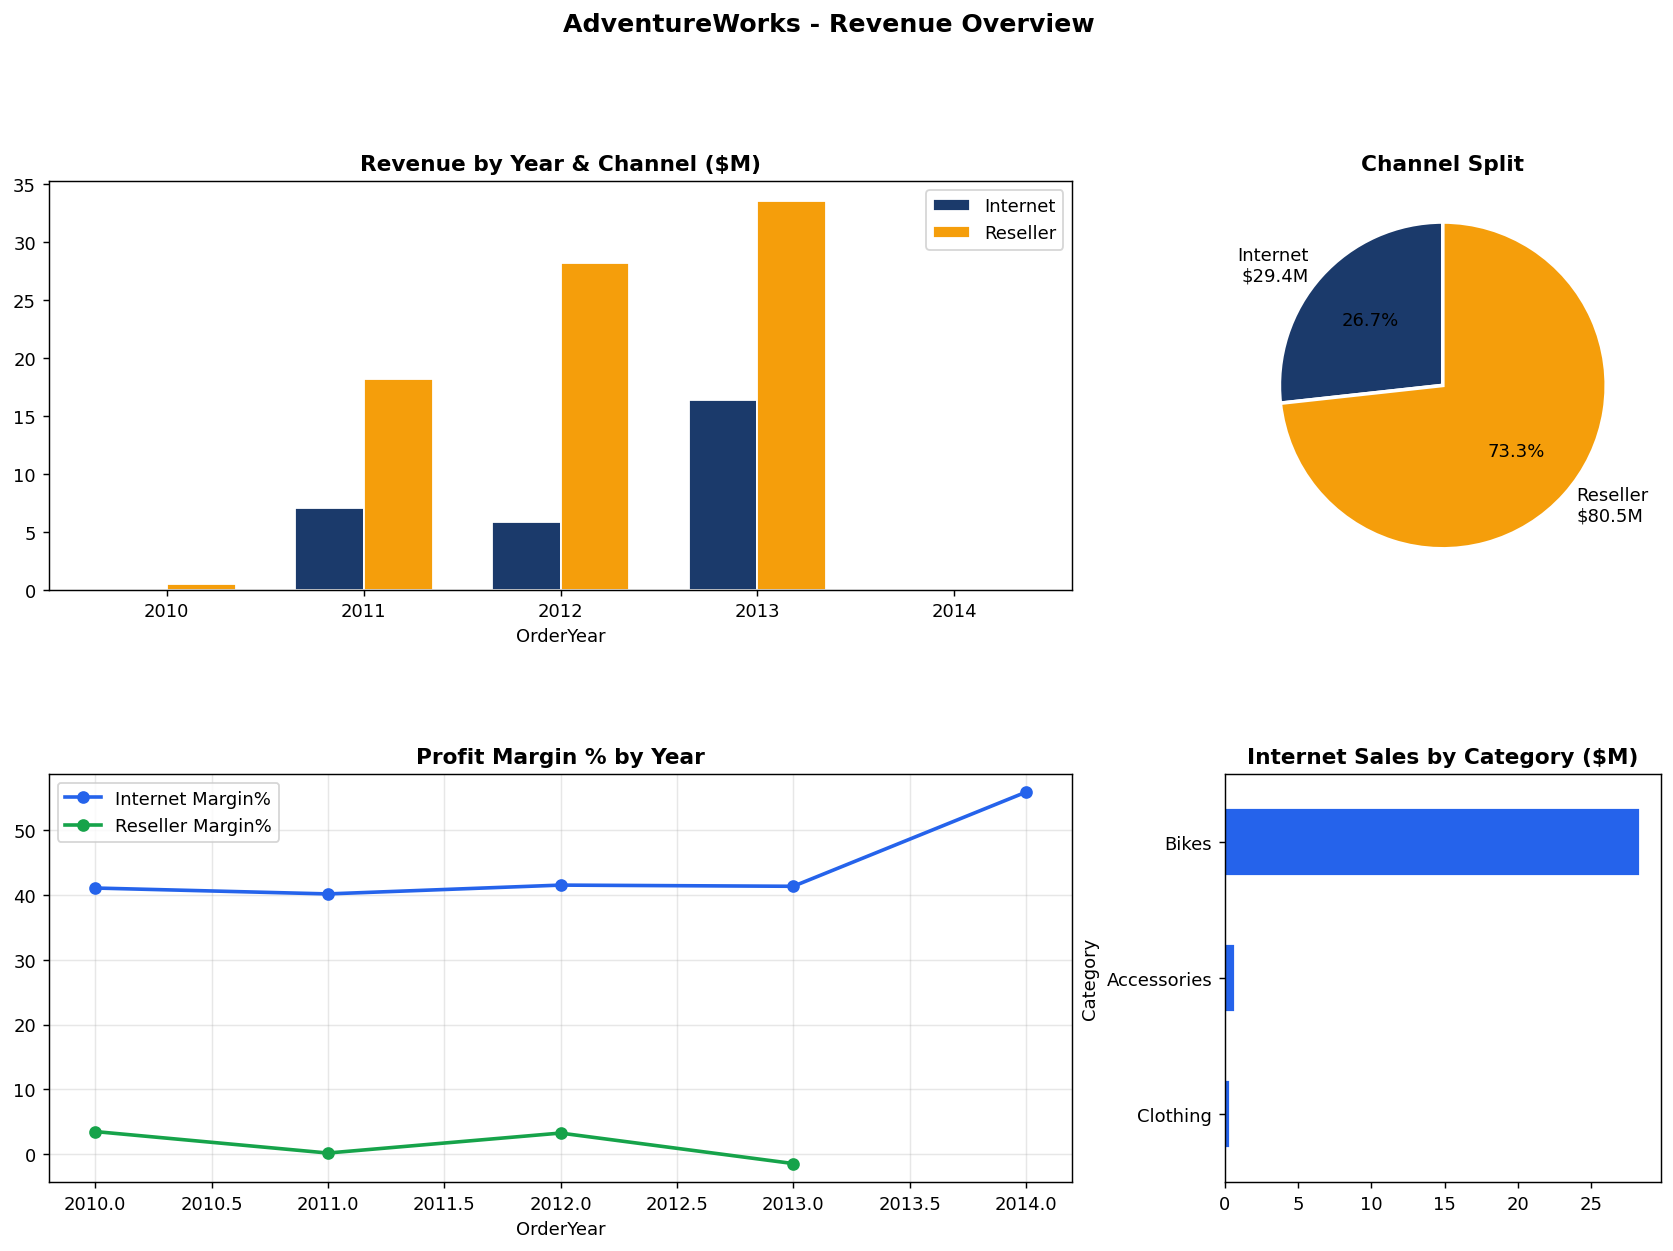

eda_overview.png saved


In [98]:
fig = plt.figure(figsize=(16,10))
gs  = gridspec.GridSpec(2,3,figure=fig,hspace=0.45,wspace=0.35)

# Revenue by Year & Channel
ax1 = fig.add_subplot(gs[0,:2])
ydf = pd.DataFrame({'Internet': fi.groupby('OrderYear')['SalesAmount'].sum()/1e6,
                    'Reseller': fr.groupby('OrderYear')['SalesAmount'].sum()/1e6}).fillna(0)
ydf.plot(kind='bar',ax=ax1,color=['#1B3A6B','#F59E0B'],edgecolor='white',width=0.7)
ax1.set_title('Revenue by Year & Channel ($M)',fontsize=12,fontweight='bold')
ax1.tick_params(axis='x',rotation=0)

# Channel donut
ax2 = fig.add_subplot(gs[0,2])
ax2.pie([ti/1e6,tr/1e6],labels=[f'Internet\n${ti/1e6:.1f}M',f'Reseller\n${tr/1e6:.1f}M'],
        autopct='%1.1f%%',colors=['#1B3A6B','#F59E0B'],
        wedgeprops={'edgecolor':'white','linewidth':2},startangle=90)
ax2.set_title('Channel Split',fontsize=12,fontweight='bold')

# Profit margin trend
ax3 = fig.add_subplot(gs[1,:2])
im = fi.groupby('OrderYear').apply(lambda d: d['Profit'].sum()/d['SalesAmount'].sum()*100)
rm = fr.groupby('OrderYear').apply(lambda d: d['Profit'].sum()/d['SalesAmount'].sum()*100)
pd.DataFrame({'Internet Margin%':im,'Reseller Margin%':rm}).plot(
    ax=ax3,marker='o',linewidth=2,color=['#2563EB','#16A34A'])
ax3.set_title('Profit Margin % by Year',fontsize=12,fontweight='bold')
ax3.grid(True,alpha=0.3)

# Category revenue
ax4 = fig.add_subplot(gs[1,2])
cat = (fi.merge(dp[['ProductKey','Category']],on='ProductKey',how='left')
        .groupby('Category')['SalesAmount'].sum()/1e6).sort_values()
cat.plot(kind='barh',ax=ax4,color='#2563EB',edgecolor='white')
ax4.set_title('Internet Sales by Category ($M)',fontsize=12,fontweight='bold')

plt.suptitle('AdventureWorks - Revenue Overview',fontsize=14,fontweight='bold',y=1.01)
plt.savefig('eda_overview.png',dpi=150,bbox_inches='tight')
plt.show()
print('eda_overview.png saved')

---
## Step 8 — RFM SEGMENTATION

In [99]:
# RFM — Recency / Frequency / Monetary segmentation

ADATE = fi['OrderDate'].max() + pd.Timedelta(days=1)

rfm = (fi.groupby('CustomerKey')
          .agg(Recency  =('OrderDate',   lambda d:(ADATE-d.max()).days),
               Frequency=('SalesOrderNumber','nunique'),
               Monetary =('SalesAmount','sum'))
          .reset_index())

rfm['R_Score'] = pd.qcut(rfm['Recency'],   q=4, labels=[4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'],  q=4, labels=[1,2,3,4]).astype(int)
rfm['RFM_Score']= rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

rfm['RFM_Segment'] = pd.cut(rfm['RFM_Score'], bins=[0,4,6,8,10,12],
                    labels=['Lost','At Risk','Potential Loyalist','Loyal','Champions'])

dc = dc.merge(rfm[['CustomerKey','Recency','Frequency','Monetary',
                    'RFM_Score','RFM_Segment']], on='CustomerKey', how='left')

print('RFM complete')
print(rfm['RFM_Segment'].value_counts())
print('\nRevenue by segment:')
print(rfm.groupby('RFM_Segment')['Monetary'].sum().sort_values(ascending=False)
     .apply(lambda x: f'${x:,.0f}'))

RFM complete
RFM_Segment
Potential Loyalist    5387
At Risk               4846
Loyal                 4236
Champions             2133
Lost                  1882
Name: count, dtype: int64

Revenue by segment:
RFM_Segment
Loyal                 $11,435,907
Champions             $10,006,128
Potential Loyalist     $6,098,594
At Risk                $1,742,423
Lost                      $75,625
Name: Monetary, dtype: object


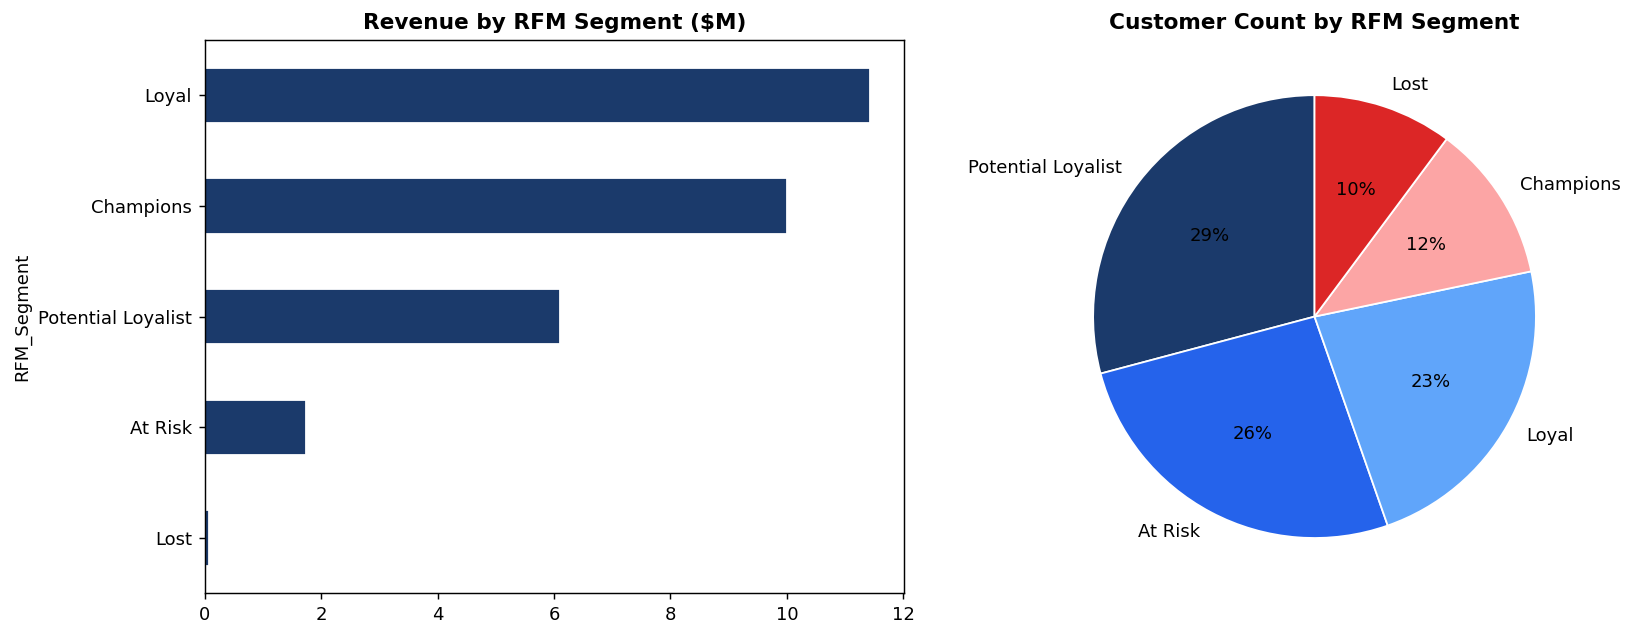

In [100]:
fig, axes = plt.subplots(1,2,figsize=(13,5))
(rfm.groupby('RFM_Segment')['Monetary'].sum().sort_values() / 1e6).plot(kind='barh', ax=axes[0], color='#1B3A6B', edgecolor='white')
axes[0].set_title('Revenue by RFM Segment ($M)',fontsize=12,fontweight='bold')
seg_cnt = rfm['RFM_Segment'].value_counts()
axes[1].pie(seg_cnt,labels=seg_cnt.index,autopct='%1.0f%%',
            colors=['#1B3A6B','#2563EB','#60A5FA','#FCA5A5','#DC2626'],
            wedgeprops={'edgecolor':'white'},startangle=90)
axes[1].set_title('Customer Count by RFM Segment',fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('eda_rfm.png',dpi=150,bbox_inches='tight')
plt.show()

---
## Step 9 — SARIMA FORECAST

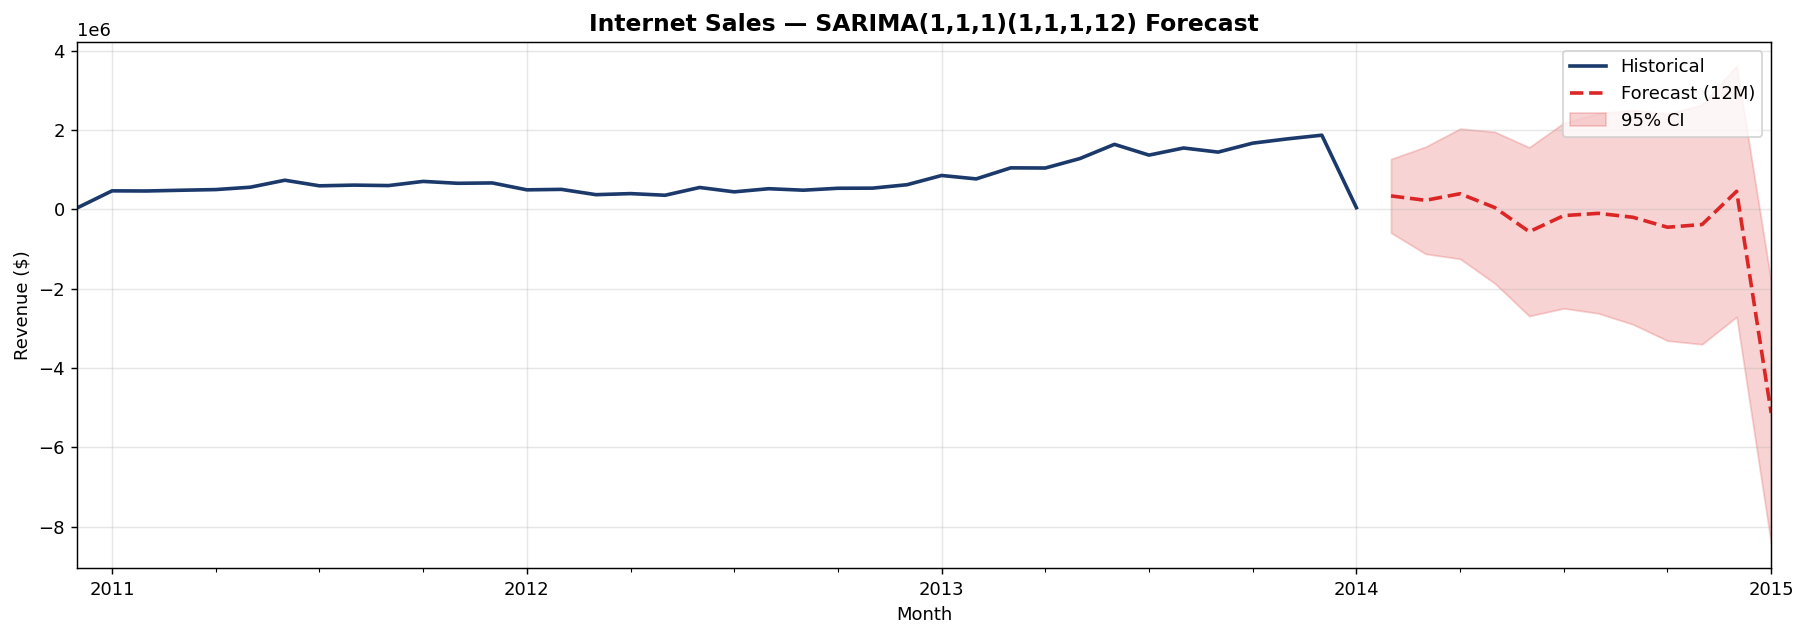

SARIMA forecast complete.  AIC=321.73  Projected 12M: $-5,497,511


In [101]:
monthly = (fi.groupby(fi['OrderDate'].dt.to_period('M'))['SalesAmount']
            .sum().reset_index())
monthly.columns = ['Month','Revenue']
monthly['Month'] = monthly['Month'].dt.to_timestamp()
monthly = monthly.sort_values('Month').set_index('Month')

try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    model   = SARIMAX(monthly['Revenue'],order=(1,1,1),seasonal_order=(1,1,1,12),
            enforce_stationarity=False,enforce_invertibility=False)
    results = model.fit(disp=False)
    fc = results.get_forecast(steps=12)
    fc_mean = fc.predicted_mean; fc_ci = fc.conf_int()

    fig, ax = plt.subplots(figsize=(14,5))
    monthly['Revenue'].plot(ax=ax,label='Historical',color='#1B3A6B',linewidth=2)
    fc_mean.plot(ax=ax,label='Forecast (12M)',color='#DC2626',linestyle='--',linewidth=2)
    ax.fill_between(fc_ci.index,fc_ci.iloc[:,0],fc_ci.iloc[:,1],alpha=0.2,color='#DC2626',label='95% CI')
    ax.set_title('Internet Sales — SARIMA(1,1,1)(1,1,1,12) Forecast',fontsize=13,fontweight='bold')
    ax.set_xlabel('Month'); ax.set_ylabel('Revenue ($)'); ax.legend(); ax.grid(True,alpha=0.3)
    plt.tight_layout()
    plt.savefig('forecast_sarima.png',dpi=150,bbox_inches='tight')
    plt.show()
    print(f'SARIMA forecast complete.  AIC={results.aic:.2f}  Projected 12M: ${fc_mean.sum():,.0f}')
except ImportError:
    print('pip install statsmodels')

---
## Step 10 — LOAD to MySQL

In [102]:
DB_USER='root'; DB_PASS='Monika#80'; DB_HOST='localhost'; DB_PORT=3306; DB_NAME='adventureworks_dw'
engine_root = create_engine(f'mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/')
with engine_root.connect() as conn:
    conn.execute(text(f'CREATE DATABASE IF NOT EXISTS {DB_NAME} CHARACTER SET utf8mb4'))
engine = create_engine(f'mysql+pymysql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}')
print('Connected to adventureworks_dw')

Connected to adventureworks_dw


In [104]:
def prep(df, date_cols_keep=None):
    df = df.copy()
    keep = set(date_cols_keep or [])
    for col in df.select_dtypes(include=['datetime64']).columns:
        if col not in keep:
            df[col] = df[col].dt.strftime('%Y-%m-%d')
    for col in df.select_dtypes(include=['category']).columns:
        df[col] = df[col].astype(str)
    return df

tables = {
    'dim_date'           :prep(dd, date_cols_keep=['FullDate']),
    'dim_customer'       :prep(dc),
    'dim_product'        :prep(dp),
    'dim_reseller'       :prep(dr),
    'dim_geography'      :prep(dg),
    'dim_sales_territory':prep(dt),
    'dim_employee'       :prep(de),
    'fact_internet_sales':prep(fi),
    'fact_reseller_sales':prep(fr),
}

for tname, df in tables.items():
    df.to_sql(tname,con=engine,if_exists='replace',index=False,chunksize=5000,method='multi')
    print(f' {tname:30s}  {len(df):>8,} rows')

print('\n All tables loaded!')

 dim_date                           2,191 rows
 dim_customer                      18,484 rows
 dim_product                          397 rows
 dim_reseller                         701 rows
 dim_geography                        655 rows
 dim_sales_territory                   11 rows
 dim_employee                          21 rows
 fact_internet_sales               60,398 rows
 fact_reseller_sales               60,855 rows

 All tables loaded!


---
## Step 11 — Export CSV for Power BI

In [105]:
os.makedirs('powerbi_data', exist_ok=True)
for tname, df in tables.items():
    df.to_csv(f'powerbi_data/{tname}.csv', index=False)
    print(f'  powerbi_data/{tname}.csv')

# Separate RFM export for Power BI
prep(rfm).to_csv('powerbi_data/rfm_segments.csv', index=False)
print('  powerbi_data/rfm_segments.csv')
print('\n All Power BI CSVs exported to powerbi_data/')

  powerbi_data/dim_date.csv
  powerbi_data/dim_customer.csv
  powerbi_data/dim_product.csv
  powerbi_data/dim_reseller.csv
  powerbi_data/dim_geography.csv
  powerbi_data/dim_sales_territory.csv
  powerbi_data/dim_employee.csv
  powerbi_data/fact_internet_sales.csv
  powerbi_data/fact_reseller_sales.csv
  powerbi_data/rfm_segments.csv

 All Power BI CSVs exported to powerbi_data/


---
## Pipeline Summary

| Step | Task | Output |
|------|------|--------|
| 1 | Extract 8 source files | ~121K rows loaded |
| 2 | 15 assertion checks | DQ report table |
| 3 | Clean + OrderDateKey INT | Efficient join keys added |
| 4 | Feature eng + Surrogate Keys | Profit, Margin, UnitPrice, AgeGroup, Segments, SKs |
| 5 | SCD Type 2 structure | EffectiveDate, EndDate, IsCurrent, RowVersion |
| 6 | DimDate 2010–2015 | 2,191 rows, 20 cols incl FiscalYear, IsHoliday |
| 7 | EDA charts | eda_overview.png |
| 8 | RFM Segmentation | 5 segments in dim_customer |
| 9 | SARIMA forecast | forecast_sarima.png |
| 10 | MySQL load | 9 tables in adventureworks_dw |
| 11 | CSV export | 10 files in powerbi_data/ |